In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path
import numpy as np

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [2]:
# ---------- DISPLAY: binary masks in a 5x3 grid ----------
def _get_mask(o):
    # prefer strict 0.5 mask if present; else fall back
    if "pred_mask_thr05" in o: return o["pred_mask_thr05"]
    return o["pred_mask"]

def show_binary_grid_5x3(outs_norm, outs_bgdr, outs_pdr, title="Binary segmentations (5×3)"):
    import matplotlib.pyplot as plt
    n_rows = max(len(outs_norm), len(outs_bgdr), len(outs_pdr))
    n_rows = min(n_rows, 5)  # you said 5 rows
    cols = 3
    fig, axes = plt.subplots(n_rows, cols, figsize=(3.6*cols, 3.6*n_rows))
    if n_rows == 1: axes = np.array([axes])
    axes = np.atleast_2d(axes)

    groups = [("Normal", outs_norm), ("BGDR", outs_bgdr), ("PDR", outs_pdr)]
    for r in range(n_rows):
        for c, (gname, outs) in enumerate(groups):
            ax = axes[r, c]
            if r < len(outs):
                m = _get_mask(outs[r]).astype(float)
                ax.imshow(m, cmap="gray", vmin=0, vmax=1); ax.axis("off")
                if r == 0:
                    ax.set_title(gname, fontsize=11)
            else:
                ax.axis("off")
    fig.suptitle(title, y=0.98, fontsize=14)
    plt.tight_layout(); plt.show()

# ---------- DISPLAY: overlays in a 5x3 grid (uses iso square) ----------
def show_overlay_grid_5x3(outs_norm, outs_bgdr, outs_pdr, draw_overlay_ax, title="Overlays (vessels + OD + PD rings)"):
    import matplotlib.pyplot as plt
    n_rows = max(len(outs_norm), len(outs_bgdr), len(outs_pdr))
    n_rows = min(n_rows, 5)
    cols = 3
    fig, axes = plt.subplots(n_rows, cols, figsize=(4.2*cols, 4.2*n_rows))
    if n_rows == 1: axes = np.array([axes])
    axes = np.atleast_2d(axes)

    groups = [("Normal", outs_norm), ("BGDR", outs_bgdr), ("PDR", outs_pdr)]
    for r in range(n_rows):
        for c, (gname, outs) in enumerate(groups):
            ax = axes[r, c]
            if r < len(outs):
                draw_overlay_ax(ax, outs[r], f"{gname} {r+1}")
                # ensure we show the square iso frame (cropped nicely)
                H, W = outs[r]["rgb_iso"].shape[:2]
                ax.set_xlim(0, W-1); ax.set_ylim(H-1, 0)
            else:
                ax.axis("off")
    fig.suptitle(title, y=0.98, fontsize=14)
    plt.tight_layout(); plt.show()


In [3]:
def make_summary_table_v4(dfN, dfB, dfP, um_scale_available=True):
    cal_key   = "caliber_um" if um_scale_available and "caliber_um" in dfN.columns else "caliber_px"
    cal_label = "Vascular caliber (µm)" if cal_key == "caliber_um" else "Vascular caliber (px)"

    rows = [
        ("Vascular fractal dimension",   "fractal_dimension"),
        ("Vascular density (%)",         "area_density_pct"),
        ("Vascular tortuosity (px⁻²)",   "tortuosity_px2"),
        (cal_label,                       cal_key),
        ("Median width (px, orth)",      "median_width_px"),
        ("IQR width (px, orth)",         "iqr_width_px"),
    ]
    def _fmt(m, s): return "—" if np.isnan(m) else f"{m:.3f} \u00B1 {s:.3f}"

    table = []
    for label, key in rows:
        Nm, Ns = dfN[key].mean(), dfN[key].std()
        Bm, Bs = dfB[key].mean(), dfB[key].std()
        Pm, Ps = dfP[key].mean(), dfP[key].std()
        table.append([label, _fmt(Nm, Ns), _fmt(Bm, Bs), _fmt(Pm, Ps)])
    return pd.DataFrame(
        table,
        columns=["Retinal vascular parameters", "Normal Mean (±SD)", "BGDR Mean (±SD)", "PDR Mean (±SD)"]
    )


def bar_global_panels_v4(
    groups, keys, titles_map, ylabels_map,
    figsize=(14, 5), bar_width=0.20, sep=0.30,
    ylims=None, ypad_frac=0.03,
    legend_top=True, legend_ncols=3, top_pad_frac=0.18
):
    """
    Draw small-multiple bar charts: one subplot per global biomarker.
    Each subplot shows all groups (e.g., Normal/BGDR/PDR) as separate bars.

    groups: list of (label, df), e.g. [("Normal", dfN), ("BGDR", dfB), ("PDR", dfP)]
    keys:   list of metric column names to plot
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from collections import OrderedDict

    # layout
    n = len(keys)
    fig, axes = plt.subplots(1, n, figsize=figsize, constrained_layout=True)
    if n == 1:
        axes = [axes]

    # reserve top space for legend
    try:
        h_in = figsize[1]
        fig.set_constrained_layout_pads(wspace=0.02, hspace=0.02, h_pad=h_in * top_pad_frac)
    except Exception:
        fig.subplots_adjust(top=1.0 - top_pad_frac, wspace=0.02)

    # x positions for each group within a panel
    G = len(groups)
    xs = np.linspace(-(G-1)/2.0, (G-1)/2.0, G) * sep

    # to build a clean legend once
    legend_items = OrderedDict()

    for ax, key in zip(axes, keys):
        means, sds = [], []

        # gather stats per group
        for gname, df in groups:
            if key in df.columns:
                m = float(df[key].mean())
                s = float(df[key].std())
            else:
                m, s = np.nan, np.nan
            means.append(m); sds.append(s)

        # draw bars
        for x_i, (gname, _df), m, s in zip(xs, groups, means, sds):
            err = None if np.isnan(s) else s
            b = ax.bar(x_i, m, yerr=err, capsize=3, width=bar_width, label=gname)
            # record a single handle per group name
            if gname not in legend_items:
                legend_items[gname] = b

        # x ticks = group names
        ax.set_xticks(xs)
        ax.set_xticklabels([g for g, _ in groups], rotation=0)
        ax.set_title(titles_map.get(key, key), fontsize=10)
        ax.set_ylabel(ylabels_map.get(key, "Value"))
        ax.grid(axis="y", alpha=0.2)
        ax.set_xlim(xs[0] - sep, xs[-1] + sep)

        # ---- robust Y-zoom (scalars) ----
        if isinstance(ylims, dict) and key in ylims and ylims[key] is not None:
            ax.set_ylim(*ylims[key])
        else:
            vals_low  = []
            vals_high = []
            for m, s in zip(means, sds):
                if np.isnan(m):
                    continue
                s = 0.0 if np.isnan(s) else s
                vals_low.append(m - s)
                vals_high.append(m + s)
            if vals_low and vals_high:
                lo = min(vals_low)
                hi = max(vals_high)
                pad = (hi - lo) * ypad_frac if hi > lo else 1.0
                ax.set_ylim(lo - pad, hi + pad)
            else:
                ax.autoscale(axis="y")

    # one legend for all panels
    handles = [legend_items[name] for name in legend_items]
    labels  = list(legend_items.keys())
    if legend_top:
        fig.legend(handles, labels, loc="upper center",
                   bbox_to_anchor=(0.5, 1.0), ncol=legend_ncols, frameon=False)
    else:
        fig.legend(handles, labels, loc="upper right", frameon=False)

    return fig, axes


def bar_rings_v4(
    groups, suffix, title, ylabel,
    bar_width=0.22, group_gap=1.0,
    ylims=None, ypad_frac=0.05
):
    """
    groups: list of (label, df)
    suffix ∈ {'fractal_dimension','area_density_pct','tortuosity_px2','caliber',
              'median_width_px','iqr_width_px'}
    """
    import numpy as np, matplotlib.pyplot as plt

    def _ring_columns(df, suffix):
        cols = [c for c in df.columns if c.endswith("|"+suffix)]
        keyed=[]
        for c in cols:
            try:
                r0 = float(c.split("|")[0].split("-")[0])
                keyed.append((r0, c))
            except: 
                pass
        return [c for _,c in sorted(keyed)]

    # intersect ring columns across all groups
    cols_all = [_ring_columns(df, suffix) for _, df in groups]
    cols = set(cols_all[0])
    for c in cols_all[1:]:
        cols = cols.intersection(c)
    cols = sorted(list(cols), key=lambda s: float(s.split("|")[0].split("-")[0]))
    if not cols:
        print(f"[warn] no common ring columns for '{suffix}'"); 
        return

    ring_labels = [c.split("|")[0].replace("PD"," PD") for c in cols]
    means = []; sds = []
    for _, df in groups:
        means.append(df[cols].mean().values)
        sds.append(df[cols].std().values)

    nR = len(cols)
    base = np.arange(nR).astype(float) * group_gap

    # offsets for K groups at each ring position
    K = len(groups)
    offs = (np.arange(K) - (K - 1) / 2.0) * bar_width

    plt.figure(figsize=(max(10, 2.2*nR), 4.2))
    for k,(gname,_df) in enumerate(groups):
        plt.bar(base + offs[k], means[k], yerr=sds[k], capsize=3,
                width=bar_width, label=gname)

    plt.xticks(base, ring_labels)
    plt.ylabel(ylabel); plt.title(title); plt.legend(); plt.grid(axis="y", alpha=0.2)

    # ---- FIXED Y-zoom block ----
    if ylims is not None:
        plt.ylim(*ylims)
    else:
        lows_list  = []
        highs_list = []
        for m, s in zip(means, sds):
            m = np.asarray(m, dtype=float)
            s = np.asarray(s, dtype=float)
            s = np.nan_to_num(s, nan=0.0)
            lows_list.append(m - s)
            highs_list.append(m + s)
        lows_all  = np.nanmin(np.concatenate(lows_list))  if lows_list  else 0.0
        highs_all = np.nanmax(np.concatenate(highs_list)) if highs_list else 1.0
        pad = (highs_all - lows_all) * ypad_frac if highs_all > lows_all else 1.0
        plt.ylim(lows_all - pad, highs_all + pad)

    plt.tight_layout(); plt.show()




In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ---------- 1) FLATTENER (global + rings; tortuosity in px^-2) ----------
def flatten_metrics_v3(out, um_per_px=None):
    """
    Returns a flat dict for tables/plots.
    Uses tortuosity in px^-2 (no PD normalization).
    Adds ring-wise fractal dimension, density, tortuosity, caliber.
    """
    bio = out["biomarkers"]
    g   = bio["global"]
    t   = bio["topology"]
    rings = bio.get("rings") or {}

    # GLOBALS
    area_density_pct = 100.0 * float(g["area_density"])          # %
    tort_px2 = float(g["tortuosity_mean"])                        # px^-2
    fracdim  = float(g["fractal_dimension"])                      # unitless

    # branching angle (not plotted below, but kept in case you need it)
    if isinstance(t.get("angles_2PD"), dict) and "angle_mean" in t["angles_2PD"]:
        angle_deg = float(t["angles_2PD"]["angle_mean"])
    else:
        angle_deg = float(t.get("angle_mean", np.nan))

    # "caliber" = median orth width; convert to µm if scale given
    median_w_px = float(g["vc_orth"]["median_width"])
    iqr_w_px    = float(g["vc_orth"]["iqr_width"])
    if um_per_px is not None:
        caliber = median_w_px * um_per_px
        caliber_field = "caliber_um"
    else:
        caliber = median_w_px
        caliber_field = "caliber_px"

    row = {
        "fractal_dimension": fracdim,
        "area_density_pct":  area_density_pct,
        "tortuosity_px2":    tort_px2,
        caliber_field:       caliber,
        # extra globals for the table
        "median_width_px":   median_w_px,
        "iqr_width_px":      iqr_w_px,
        "angle_mean_deg":    angle_deg,
    }

    # RINGS (use 0.5–2.5 PD like the paper figure)
    wanted_starts = [0.5, 1.0, 1.5, 2.0]
    for k, r in rings.items():
        try:
            r0 = float(k.split("-")[0])
        except:
            continue
        if r0 not in wanted_starts:
            continue

        # ring metrics
        row[f"{k}|fractal_dimension"]  = float(r.get("fractal_dimension", np.nan))
        row[f"{k}|area_density_pct"]   = 100.0 * float(r.get("area_density", np.nan))
        row[f"{k}|tortuosity_px2"]     = float(r.get("tortuosity_mean", np.nan))  # px^-2

        r_med_w_px = float(r.get("median_width", np.nan))
        if um_per_px is not None:
            row[f"{k}|caliber"] = r_med_w_px * um_per_px
            row[f"{k}|caliber_unit"] = "µm"
        else:
            row[f"{k}|caliber"] = r_med_w_px
            row[f"{k}|caliber_unit"] = "px"

    return row

# ---------- 2) SUMMARY TABLE (adds Median/IQR width in px) ----------
def make_summary_table_v3(dfN, dfD, um_scale_available=True):
    """
    Columns:
      Retinal vascular parameters | Normal Mean (±SD) | DR Mean (±SD)
    Includes Median/IQR width (px) in the global table.
    """
    cal_key   = "caliber_um" if um_scale_available and "caliber_um" in dfN.columns else "caliber_px"
    cal_label = "Vascular caliber (µm)" if cal_key == "caliber_um" else "Vascular caliber (px)"

    rows = [
        ("Vascular fractal dimension",   "fractal_dimension"),
        ("Vascular density (%)",         "area_density_pct"),
        ("Vascular tortuosity (px⁻²)",   "tortuosity_px2"),
        (cal_label,                       cal_key),
        ("Median width (px, orth)",      "median_width_px"),
        ("IQR width (px, orth)",         "iqr_width_px"),
    ]

    def _fmt(mean, sd):
        return "—" if np.isnan(mean) else f"{mean:.3f} \u00B1 {sd:.3f}"

    table = []
    for label, key in rows:
        Nm, Ns = dfN[key].mean(), dfN[key].std()
        Dm, Ds = dfD[key].mean(), dfD[key].std()
        table.append([label, _fmt(Nm, Ns), _fmt(Dm, Ds)])

    return pd.DataFrame(table, columns=["Retinal vascular parameters", "Normal Mean (±SD)", "DR Mean (±SD)"])

# ---------- 3) GLOBAL BAR COMPARISON (4 metrics only) ----------
def bar_global_v3(dfN, dfD, keys, label_map, title):
    meansN, sdsN = dfN[keys].mean(), dfN[keys].std()
    meansD, sdsD = dfD[keys].mean(), dfD[keys].std()

    x = np.arange(len(keys)).astype(float)
    w = 0.28   # thinner bars
    # space groups a bit
    x = x * 1.4

    plt.figure(figsize=(12, 4.2))
    plt.bar(x - w/2, meansN.values, yerr=sdsN.values, capsize=3, width=w, label="Normal")
    plt.bar(x + w/2, meansD.values, yerr=sdsD.values, capsize=3, width=w, label="DR")
    plt.xticks(x, [label_map[k] for k in keys], rotation=15, ha="right")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# ---------- 4) RING-WISE BAR CHARTS (thinner bars + gaps) ----------

def bar_rings_v3(
    dfN, dfD, suffix, title, ylabel,
    bar_width=0.28,          # <- thinner/thicker bars
    group_gap=1,           # <- multiply spacing between ring groups
    ylims=None,              # <- (ymin, ymax) to zoom Y
    ypad_frac=0.05
):
    """
    suffix ∈ {'fractal_dimension','area_density_pct','tortuosity_px2','caliber',
              'median_width_px','iqr_width_px'}
    """
    import numpy as np
    import matplotlib.pyplot as plt

    def _ring_columns(df, suffix):
        cols = [c for c in df.columns if c.endswith("|"+suffix)]
        keyed = []
        for c in cols:
            try:
                r0 = float(c.split("|")[0].split("-")[0])
                keyed.append((r0, c))
            except:
                pass
        return [c for _, c in sorted(keyed)]

    colsN = _ring_columns(dfN, suffix)
    colsD = _ring_columns(dfD, suffix)
    cols  = [c for c in colsN if c in colsD]
    if not cols:
        print(f"[warn] no ring columns found for '{suffix}'"); 
        return

    ring_labels = [c.split("|")[0].replace("PD"," PD") for c in cols]
    mN, sN = dfN[cols].mean().values, dfN[cols].std().values
    mD, sD = dfD[cols].mean().values, dfD[cols].std().values

    # positions: widen gaps between each ring group
    base = np.arange(len(cols)).astype(float) * group_gap

    plt.figure(figsize=(10, 4.2))
    plt.bar(base - bar_width/2, mN, yerr=sN, capsize=3, width=bar_width, label="Normal")
    plt.bar(base + bar_width/2, mD, yerr=sD, capsize=3, width=bar_width, label="DR")
    plt.xticks(base, ring_labels)
    plt.ylabel(ylabel); plt.title(title)
    plt.legend(); plt.grid(axis="y", alpha=0.2)

    # Y zoom
    if ylims is not None:
        plt.ylim(*ylims)
    else:
        lo = float(np.nanmin([mN - (sN or 0), mD - (sD or 0)]))
        hi = float(np.nanmax([mN + (sN or 0), mD + (sD or 0)]))
        pad = (hi - lo) * ypad_frac if hi > lo else 1.0
        plt.ylim(lo - pad, hi + pad)

    plt.tight_layout(); plt.show()

def bar_global_panels(dfN, dfD, keys, titles_map, ylabels_map,
                      figsize=(12, 3.4), bar_width=0.24):
    """
    Draw small-multiple bar charts: one subplot per global biomarker.
    Each subplot shows Normal vs DR (mean ± SD).
    """
    import numpy as np
    import matplotlib.pyplot as plt

    n = len(keys)
    fig, axes = plt.subplots(1, n, figsize=figsize, constrained_layout=True)
    if n == 1:
        axes = [axes]

    # consistent x positions for Normal vs DR
    x = np.array([0, 1])

    for ax, key in zip(axes, keys):
        mN, sN = dfN[key].mean(), dfN[key].std()
        mD, sD = dfD[key].mean(), dfD[key].std()

        ax.bar(x[0], mN, yerr=sN, capsize=3, width=bar_width, label="Normal")
        ax.bar(x[1], mD, yerr=sD, capsize=3, width=bar_width, label="DR")

        ax.set_xticks(x); ax.set_xticklabels(["Normal", "DR"])
        ax.set_title(titles_map.get(key, key), fontsize=10)
        ax.set_ylabel(ylabels_map.get(key, "Value"))
        ax.tick_params(axis="x", labelrotation=0)
        ax.grid(axis="y", alpha=0.2)

    # single shared legend (top-right)
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=False)
    return fig, axes



# ---------- GLOBAL (4 metrics), each in its own small panel ----------
def bar_global_panels(
    dfN, dfD, keys, titles_map, ylabels_map,
    figsize=(12, 4),
    bar_width=0.24,
    pair_sep=0.60,
    panel_wspace=0.02,
    ylims=None,
    ypad_frac=0.05,
    # NEW:
    legend_top=True,
    legend_ncols=2,
    top_pad_frac=0.15   # fraction of figure height to reserve at the top
):
    import numpy as np
    import matplotlib.pyplot as plt

    if bar_width >= pair_sep:
        bar_width = max(0.01, pair_sep * 0.45)

    n = len(keys)
    fig, axes = plt.subplots(1, n, figsize=figsize, constrained_layout=True)
    if n == 1:
        axes = [axes]

    # tighten inter-panel spacing + reserve top margin
    try:
        # h_pad is in inches; estimate from figure height
        h_in = figsize[1]
        fig.set_constrained_layout_pads(
            wspace=panel_wspace,
            hspace=0.02,
            h_pad=h_in * top_pad_frac
        )
    except Exception:
        # fallback if constrained_layout pads unavailable
        fig.subplots_adjust(top=1.0 - top_pad_frac, wspace=panel_wspace)

    x = np.array([-pair_sep/2.0, pair_sep/2.0])  # [Normal, DR] centers

    for ax, key in zip(axes, keys):
        mN, sN = dfN[key].mean(), dfN[key].std()
        mD, sD = dfD[key].mean(), dfD[key].std()

        ax.bar(x[0], mN, yerr=sN, capsize=3, width=bar_width, label="Normal")
        ax.bar(x[1], mD, yerr=sD, capsize=3, width=bar_width, label="DR")

        ax.set_xticks(x); ax.set_xticklabels(["Normal", "DR"])
        ax.set_title(titles_map.get(key, key), fontsize=10)
        ax.set_ylabel(ylabels_map.get(key, "Value"))
        ax.grid(axis="y", alpha=0.2)
        ax.set_xlim(-pair_sep, pair_sep)

        # y-zoom / auto
        if isinstance(ylims, dict) and key in ylims and ylims[key] is not None:
            ax.set_ylim(*ylims[key])
        else:
            lo = float(min(mN - (sN or 0), mD - (sD or 0)))
            hi = float(max(mN + (sN or 0), mD + (sD or 0)))
            pad = (hi - lo) * ypad_frac if hi > lo else 1.0
            ax.set_ylim(lo - pad, hi + pad)

    # move legend to top center, outside plots
    handles, labels = axes[-1].get_legend_handles_labels()
    if legend_top:
        fig.legend(handles, labels, loc="upper center",
                   bbox_to_anchor=(0.5, 1.0), ncol=legend_ncols, frameon=False)
    else:
        fig.legend(handles, labels, loc="upper right", frameon=False)

    return fig, axes



In [5]:
from src.retina_biomarkers.notebook_utils.pipeline.config import PipelineConfig
from src.retina_biomarkers.notebook_utils.pipeline.retina import run_pipeline
from src.retina_biomarkers.notebook_utils.report.compare import (
    draw_overlay_ax,         # overlay helper
    # flatten_metrics_v3,      # your flattener
    # make_summary_table_v3,   # summary table (adds median/IQR width)
    # bar_global_panels,       # small-multiple global bars
    # bar_rings_v3,            # ring-wise bars with spacing
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cfg = PipelineConfig()
ckpt_path = "../../outputs/checkpoints/final/[DRIVE] dpcn_refineEdge.pth"

normal_paths = [
    "../../data/raw/DR_sampleset/normal1.png", # right
    "../../data/raw/DR_sampleset/normal2.png", # left
    "../../data/raw/DR_sampleset/normal3.png", # left
    "../../data/raw/DR_sampleset/normal4.png", # right
    "../../data/raw/DR_sampleset/normal5.png", # right
]
bgdr_paths = [
    "../../data/raw/DR_sampleset/bgdr1.png", # right
    "../../data/raw/DR_sampleset/bgdr2.png", # left
    "../../data/raw/DR_sampleset/bgdr3.png", # left
    "../../data/raw/DR_sampleset/bgdr4.png", # right
    "../../data/raw/DR_sampleset/bgdr5.png", # left
]
pdr_paths = [
    "../../data/raw/DR_sampleset/pdr1.png", # left
    "../../data/raw/DR_sampleset/pdr2.png", # right 
    #"../../data/raw/DR_sampleset/pdr3.png", # left
    "../../data/raw/DR_sampleset/pdr4.png", # right  
    "../../data/raw/DR_sampleset/pdr5.png", # left
    "../../data/raw/DR_sampleset/pdr6.png",
] 

normal_paths_fovea = [
    "../../data/raw/DR_sampleset/normal1_fovea.png",
    "../../data/raw/DR_sampleset/normal2_fovea.png",
    "../../data/raw/DR_sampleset/normal3_fovea.png",
    "../../data/raw/DR_sampleset/normal4_fovea.png",
    "../../data/raw/DR_sampleset/normal5_fovea.png",
]
bgdr_paths_fovea = [
    "../../data/raw/DR_sampleset/bgdr1_fovea.png",
    "../../data/raw/DR_sampleset/bgdr2_fovea.png",
    "../../data/raw/DR_sampleset/bgdr3_fovea.png",
    "../../data/raw/DR_sampleset/bgdr4_fovea.png",
    "../../data/raw/DR_sampleset/bgdr5_fovea.png",
]
pdr_paths_fovea = [
    "../../data/raw/DR_sampleset/pdr1_fovea.png",
    "../../data/raw/DR_sampleset/pdr2_fovea.png",
    #"../../data/raw/DR_sampleset/pdr3_fovea.png",
    "../../data/raw/DR_sampleset/pdr4_fovea.png",
    "../../data/raw/DR_sampleset/pdr5_fovea.png",
    "../../data/raw/DR_sampleset/pdr6_fovea.png",
]


normal_paths_fov = [
    "../../data/raw/DR_sampleset/normal1_fov.png",
    "../../data/raw/DR_sampleset/normal2_fov.png",
    "../../data/raw/DR_sampleset/normal3_fov.png",
    "../../data/raw/DR_sampleset/normal4_fov.png",
    "../../data/raw/DR_sampleset/normal5_fov.png",
]
bgdr_paths_fov = [
    "../../data/raw/DR_sampleset/bgdr1_fov.png",
    "../../data/raw/DR_sampleset/bgdr2_fov.png",
    "../../data/raw/DR_sampleset/bgdr3_fov.png",
    "../../data/raw/DR_sampleset/bgdr4_fov.png",
    "../../data/raw/DR_sampleset/bgdr5_fov.png",
]
pdr_paths_fov = [
    "../../data/raw/DR_sampleset/pdr1_fov.png",
    "../../data/raw/DR_sampleset/pdr2_fov.png",
    #"../../data/raw/DR_sampleset/pdr3_fov.png",
    "../../data/raw/DR_sampleset/pdr4_fov.png",
    "../../data/raw/DR_sampleset/pdr5_fov.png",
    "../../data/raw/DR_sampleset/pdr6_fov.png",
]

def run_list(paths):
    outs = []
    for p in paths:
        try:
            outs.append(run_pipeline(p, ckpt_path, cfg=cfg))
        except Exception as e:
            print(f"[warn] failed on {p}: {e}")
    return outs


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


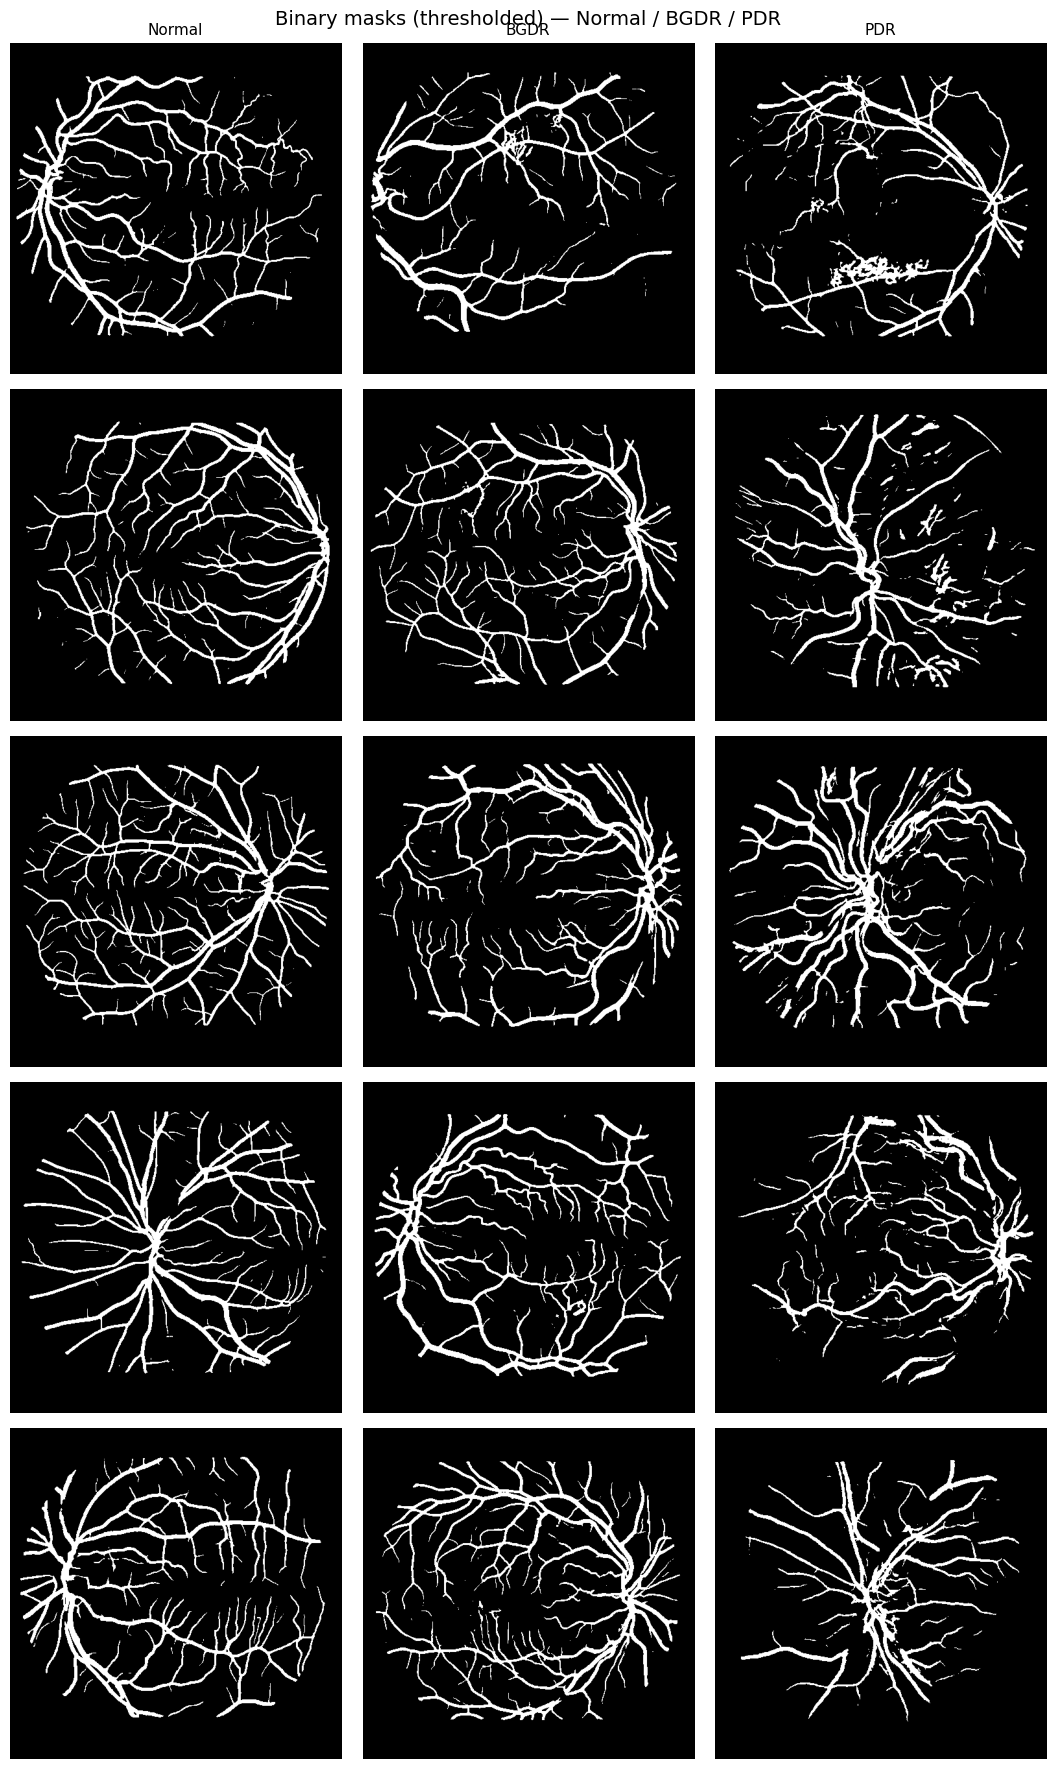

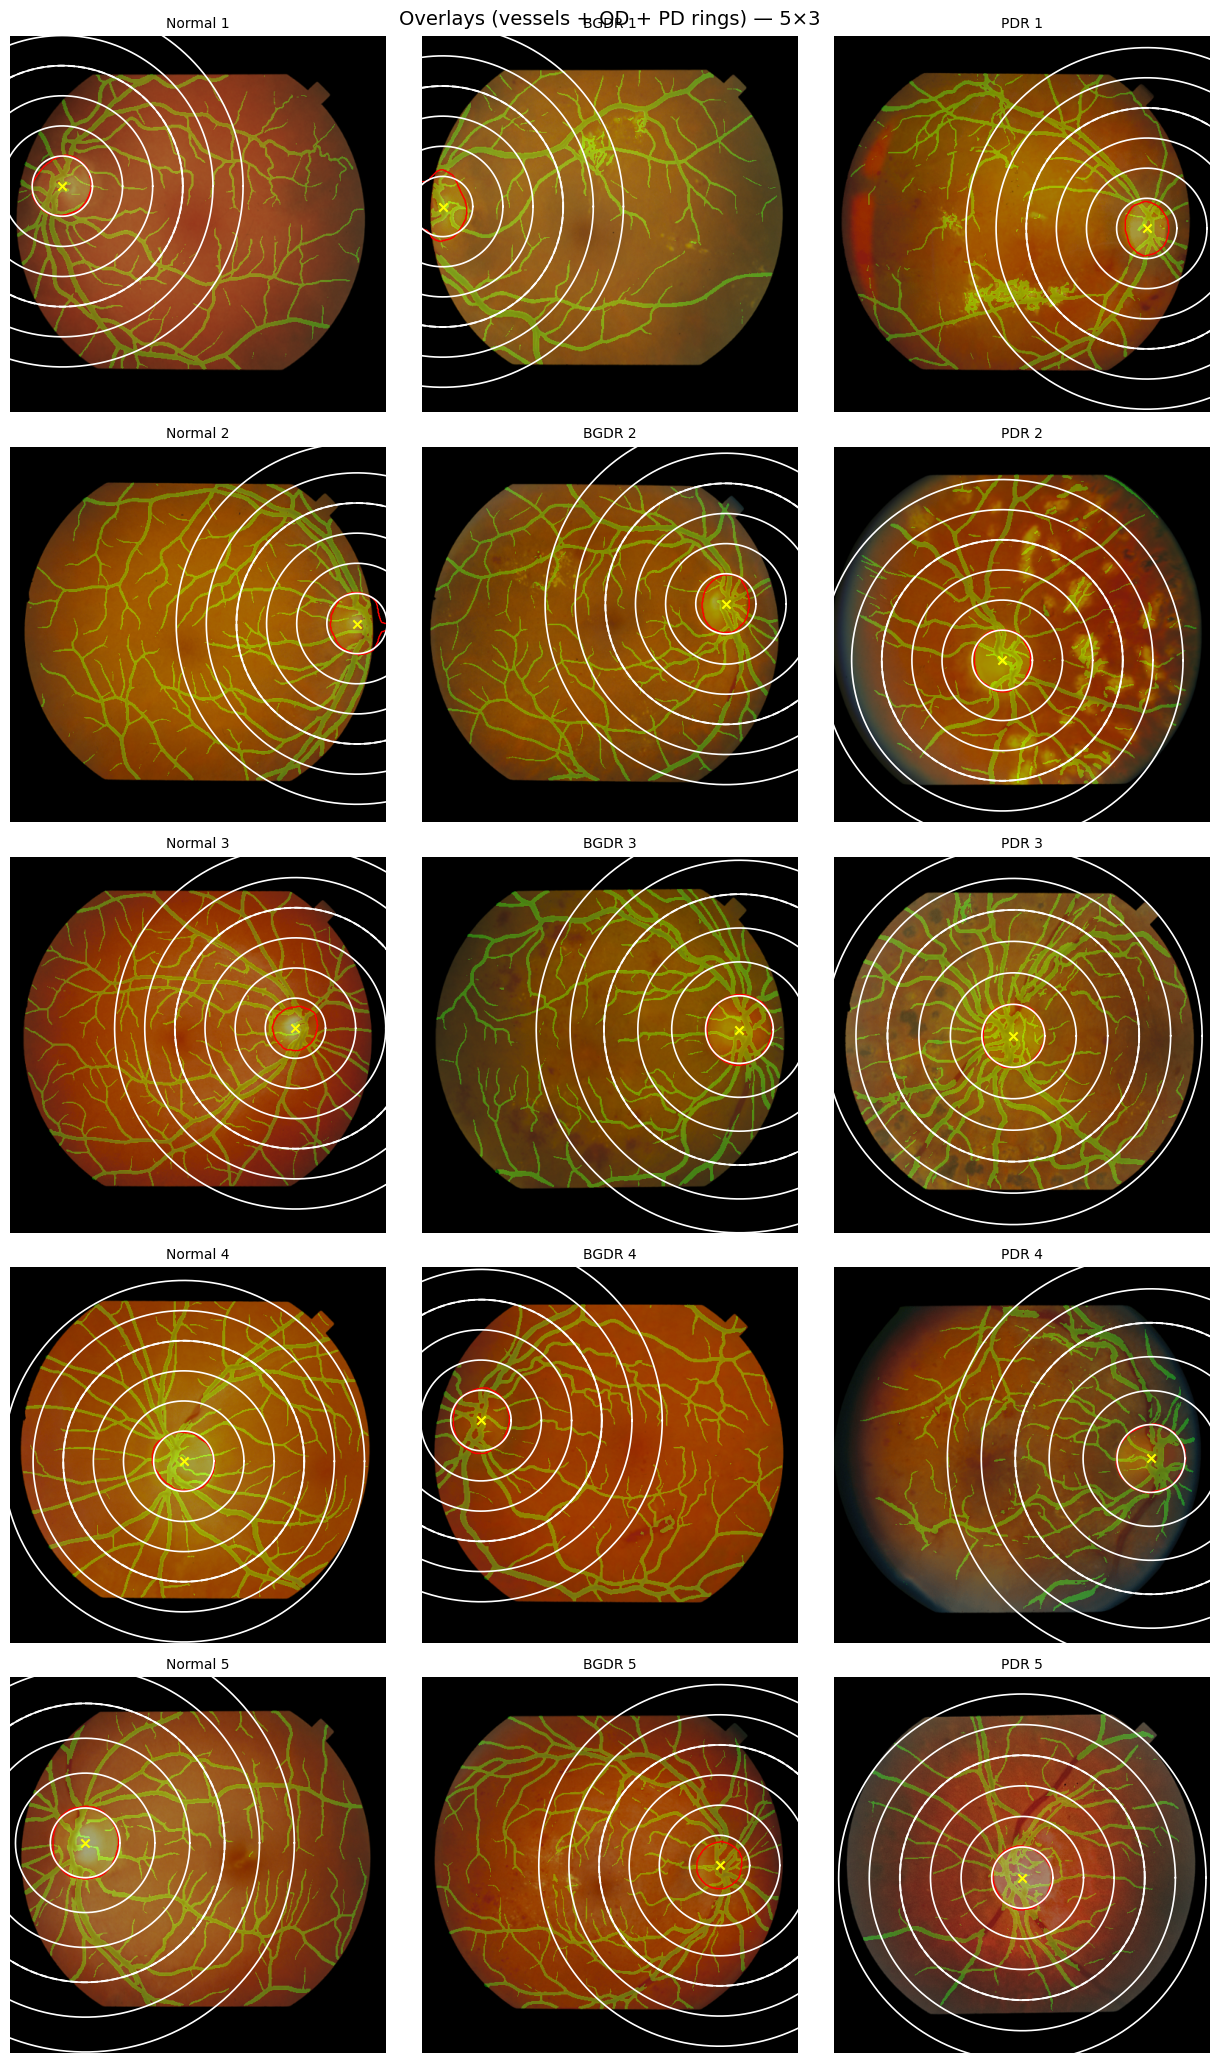

,Retinal vascular parameters,Normal Mean (±SD),BGDR Mean (±SD),PDR Mean (±SD)
0,Vascular fractal dimension,1.510 ± 0.019,1.496 ± 0.030,1.463 ± 0.028
1,Vascular density (%),10.381 ± 0.286,9.937 ± 1.139,9.100 ± 1.757
2,Vascular tortuosity (px⁻²),0.185 ± 0.006,0.185 ± 0.007,0.184 ± 0.009
3,Vascular caliber (px),4.900 ± 0.224,4.800 ± 0.447,5.200 ± 0.447
4,"Median width (px, orth)",4.900 ± 0.224,4.800 ± 0.447,5.200 ± 0.447
5,"IQR width (px, orth)",3.900 ± 0.224,4.200 ± 0.758,4.800 ± 0.274


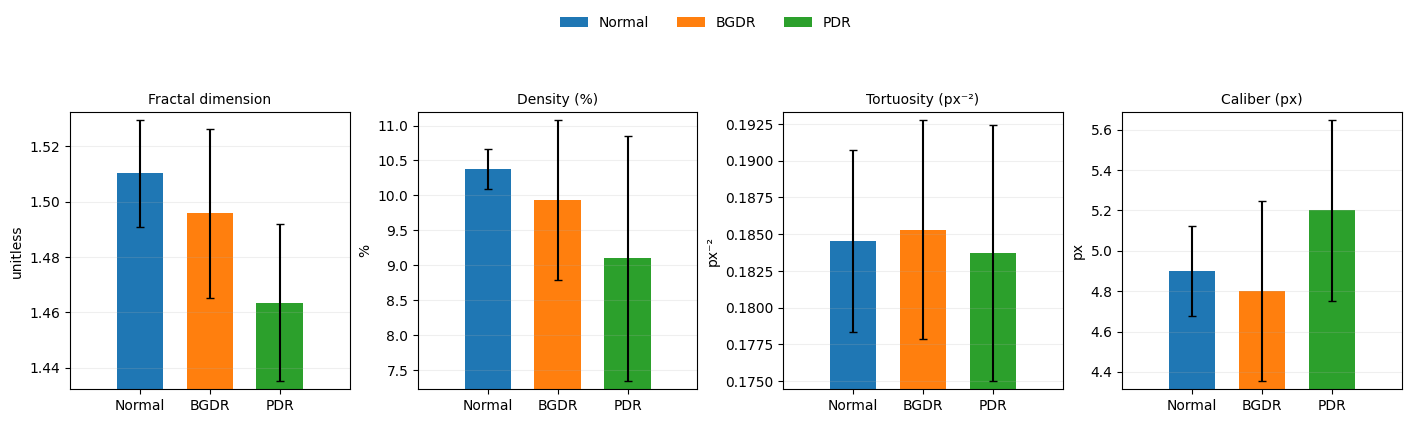

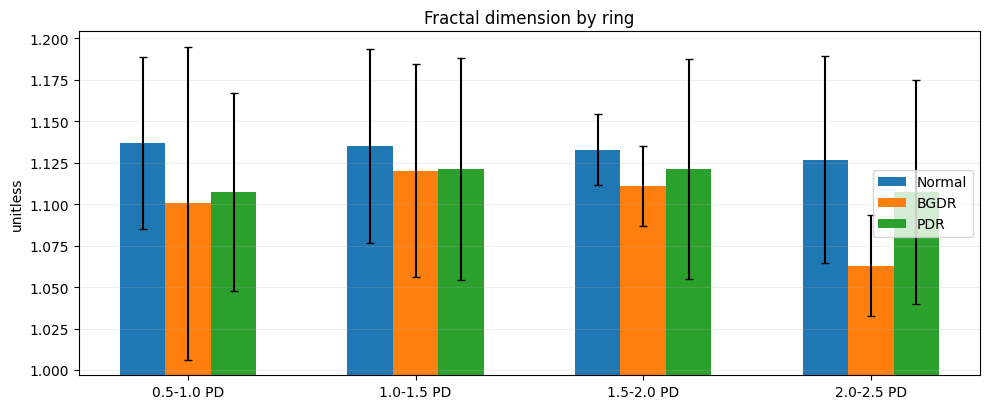

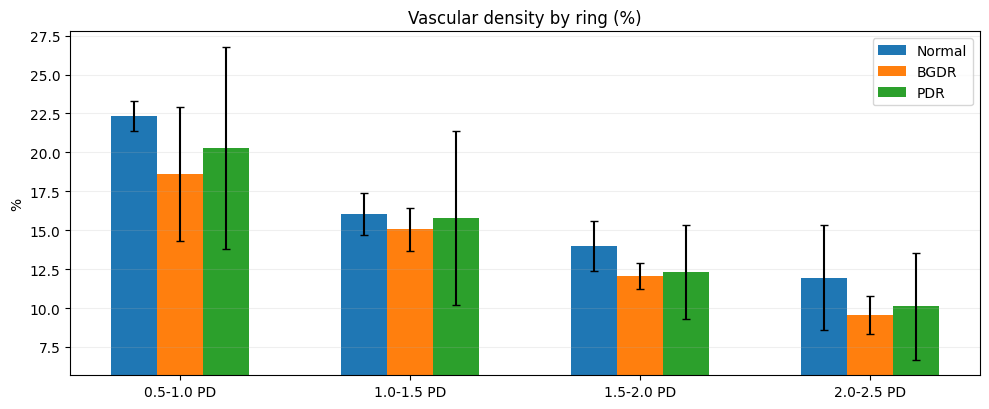

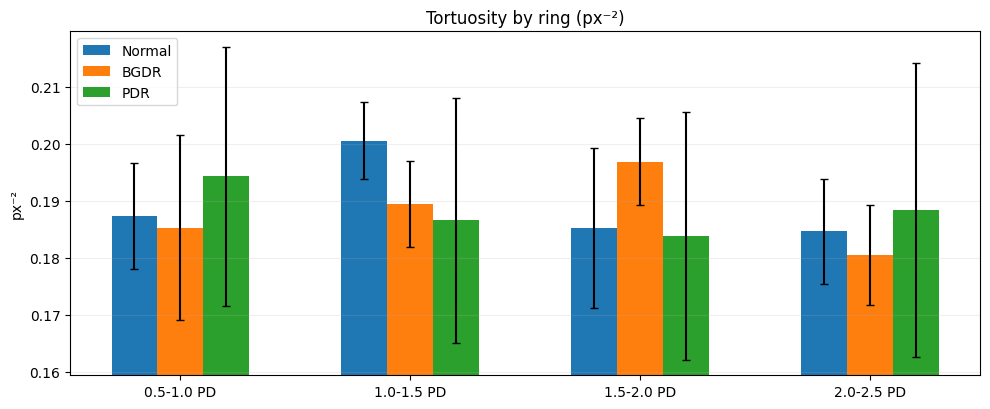

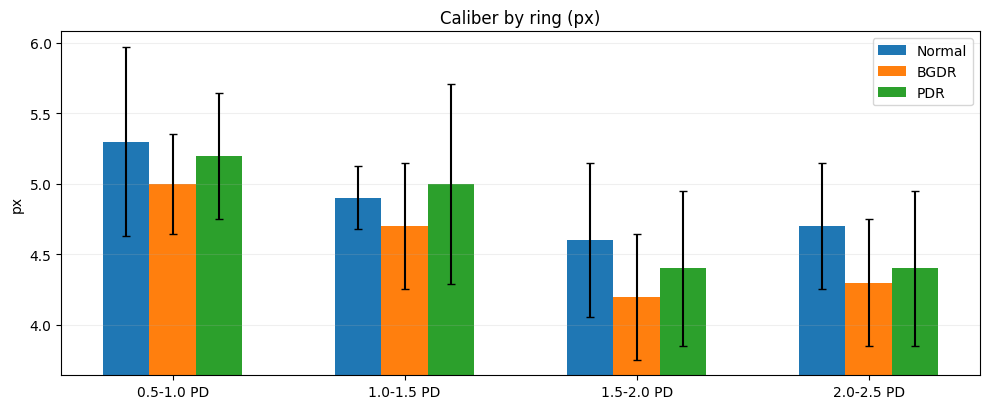

In [6]:
# 1) Run all three groups
outs_norm = run_list(normal_paths)
outs_bgdr = run_list(bgdr_paths)
outs_pdr  = run_list(pdr_paths)

# 2) Show ALL binary segmentations first (5×3)
show_binary_grid_5x3(outs_norm, outs_bgdr, outs_pdr, title="Binary masks (thresholded) — Normal / BGDR / PDR")

# 3) Then show the 5×3 overlays (square iso frame, rings inside)
show_overlay_grid_5x3(outs_norm, outs_bgdr, outs_pdr, draw_overlay_ax,
                      title="Overlays (vessels + OD + PD rings) — 5×3")

# 4) Flatten → DataFrames (set um_per_px if you have scale)
dfN = pd.DataFrame([flatten_metrics_v3(o, um_per_px=None) for o in outs_norm])
dfB = pd.DataFrame([flatten_metrics_v3(o, um_per_px=None) for o in outs_bgdr])
dfP = pd.DataFrame([flatten_metrics_v3(o, um_per_px=None) for o in outs_pdr])

# 5) Summary table (Normal, BGDR, PDR)
tbl = make_summary_table_v4(dfN, dfB, dfP, um_scale_available=("caliber_um" in dfN.columns))
from IPython.display import display
display(tbl)

# 6) Global bars (4 metrics), now 3 groups
cal_key = "caliber_um" if "caliber_um" in dfN.columns else "caliber_px"
keys = ["fractal_dimension", "area_density_pct", "tortuosity_px2", cal_key]
titles_map = {
    "fractal_dimension": "Fractal dimension",
    "area_density_pct":  "Density (%)",
    "tortuosity_px2":    "Tortuosity (px⁻²)",
    cal_key:             "Caliber (µm)" if cal_key == "caliber_um" else "Caliber (px)",
}
ylabels_map = {
    "fractal_dimension": "unitless",
    "area_density_pct":  "%",
    "tortuosity_px2":    "px⁻²",
    cal_key:             ("µm" if cal_key == "caliber_um" else "px"),
}
global_ylims = {
    # edit to your ranges if you want tighter zooms:
    # "fractal_dimension": (1.40, 1.55),
    # "area_density_pct":  (7.0, 10.5),
    # "tortuosity_px2":    (0.16, 0.20),
    # cal_key:             (3.5, 5.5),
}

bar_global_panels_v4(
    groups=[("Normal", dfN), ("BGDR", dfB), ("PDR", dfP)],
    keys=keys, titles_map=titles_map, ylabels_map=ylabels_map,
    figsize=(14, 5), bar_width=0.20, sep=0.30,
    ylims=global_ylims or None, ypad_frac=0.03,
    legend_top=True, legend_ncols=3, top_pad_frac=0.18
)

# 7) Ring-wise bars (3 groups). Adjust ylims as needed.
unit = "µm" if "caliber_um" in dfN.columns else "px"
bar_rings_v4([("Normal", dfN), ("BGDR", dfB), ("PDR", dfP)],
             "fractal_dimension", "Fractal dimension by ring", "unitless",
             bar_width=0.20, group_gap=1.0)

bar_rings_v4([("Normal", dfN), ("BGDR", dfB), ("PDR", dfP)],
             "area_density_pct", "Vascular density by ring (%)", "%",
             bar_width=0.20, group_gap=1.0)

bar_rings_v4([("Normal", dfN), ("BGDR", dfB), ("PDR", dfP)],
             "tortuosity_px2", "Tortuosity by ring (px⁻²)", "px⁻²",
             bar_width=0.20, group_gap=1.0)

bar_rings_v4([("Normal", dfN), ("BGDR", dfB), ("PDR", dfP)],
             "caliber", f"Caliber by ring ({unit})", unit,
             bar_width=0.20, group_gap=1.0)


d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


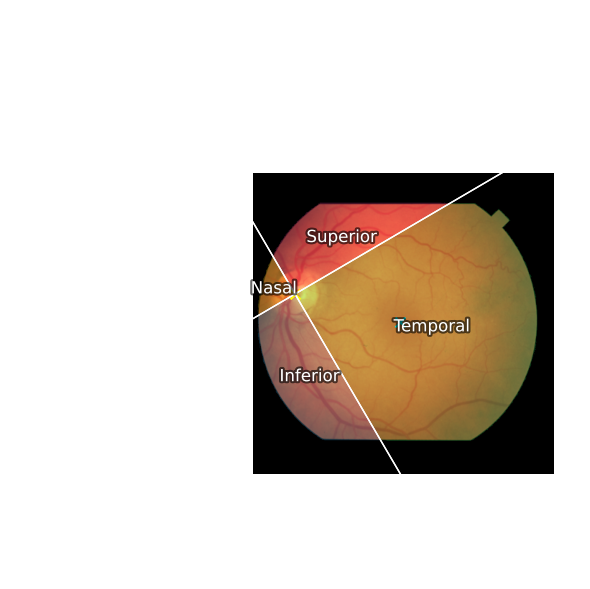

In [7]:
from src.retina_biomarkers.isnt_quadrants import (
    prepare_isnt_for_image, draw_isnt_quadrants, compute_biomarkers_per_quadrant
)
from src.retina_biomarkers.notebook_utils.pipeline.retina import run_pipeline  # your existing pipeline

ckpt_path  = "../../outputs/checkpoints/final/[DRIVE] dpcn_refineEdge.pth"
color_path = "../../data/raw/DR_sampleset/normal1.png"
fovea_path = "../../data/raw/DR_sampleset/normal1_fovea.png"
fov_path   = "../../data/raw/DR_sampleset/normal1_fov.png"   # or None

# 1) Get disc center, PD, fovea, FOV, and ISNT masks
geo = prepare_isnt_for_image(color_path, fovea_path, fov_path=fov_path, sector_deg=90.0)

# 2) Run your vessel pipeline to get the segmentation mask & biomarkers
out = run_pipeline(color_path, ckpt_path, fov_path=fov_path)  # returns 'pred_mask', 'biomarkers', etc.

# 3) Compute per-quadrant biomarkers by masking the vessel map
per_quad = compute_biomarkers_per_quadrant(
    out["pred_mask"],
    disc_center_yx=geo["disc_center_yx"],
    PD_px=geo["PD_px"],
    quadrant_masks=geo["isnt_masks"],
    # You can pass extra kwargs used by compute_biomarkers_from_mask_array:
    max_gap_px=12, angle_k_ahead=3, ortho_step=0.5, ortho_max_radius=20.0
)

# 4) Visualize the quadrants (labels follow the fovea direction)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
draw_isnt_quadrants(ax, geo["rgb_iso"], geo["isnt_masks"], geo["disc_center_yx"], geo["fovea_yx"])
plt.tight_layout(); plt.show()


In [ ]:
import numpy as np
import pandas as pd

def flatten_quadrants_row(per_quad: dict, um_per_px=None):
    """
    per_quad: dict keyed by {'I','S','N','T'}; each value has metrics
              like fractal_dimension, area_density, tortuosity_mean,
              and either 'median_width' or vc_orth['median_width'].
    Returns a flat dict with keys like 'I|fractal_dimension', 'S|caliber', etc.
    """
    def _get_caliber(q):
        # prefer direct median_width; fallback to vc_orth dict if present
        if isinstance(q, dict) and "median_width" in q:
            return float(q["median_width"])
        if isinstance(q, dict) and "vc_orth" in q and "median_width" in q["vc_orth"]:
            return float(q["vc_orth"]["median_width"])
        return np.nan

    row = {}
    for qk in ["I", "S", "N", "T"]:     # ISNT order
        q = per_quad.get(qk, {}) or {}

        # core metrics
        fracdim = float(q.get("fractal_dimension", np.nan))
        area_pct = 100.0 * float(q.get("area_density", np.nan))
        tort_px2 = float(q.get("tortuosity_mean", np.nan))
        calib_px = _get_caliber(q)

        row[f"{qk}|fractal_dimension"] = fracdim
        row[f"{qk}|area_density_pct"]  = area_pct
        row[f"{qk}|tortuosity_px2"]    = tort_px2

        if um_per_px is not None and np.isfinite(calib_px):
            row[f"{qk}|caliber"] = calib_px * float(um_per_px)
            row[f"{qk}|caliber_unit"] = "µm"
        else:
            row[f"{qk}|caliber"] = calib_px
            row[f"{qk}|caliber_unit"] = "px"

    return row


{'T': {'image_shape': (512, 512), 'global': {'area_density': 0.040679931640625, 'length_density_px_inv': 0.015727902040907793, 'fractal_dimension': 1.3739191729200926, 'tortuosity_mean': 0.18946243822574615, 'vc_edt': {'median_width': 2.8284270763397217, 'iqr_width': 2.0, 'frac_thin_len': 0.8224212476837554, 'frac_med_len': 0.1775787523162446, 'frac_thick_len': 0.0}, 'vc_orth': {'median_width': 3.0, 'iqr_width': 2.5, 'frac_thin_len': 0.6622245002562789, 'frac_med_len': 0.2685802152742183, 'frac_thick_len': 0.06919528446950282}, 'median_width': 3.0, 'iqr_width': 2.5, 'median_width_PD': 0.029296875, 'iqr_width_PD': 0.0244140625, 'length_density_PD_inv': 164.91900610446933, 'tortuosity_mean_PD2': 1986.6576562500004, 'tortuosity_mean_PD2_x1e3': 1986657.6562500005}, 'topology': {'junction_count': 169.0, 'endpoint_count': 137.0, 'junction_density': 0.000644683837890625, 'endpoint_density': 0.000522613525390625, 'angle_mean': 111.42557525634766, 'angle_std': 48.70032501220703, 'angle_p10': 45